<a href="https://colab.research.google.com/github/DanielSammaritani/Simple_Trading_Strategy/blob/main/Strategia_di_Trading_sulle_medie_mobili.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The strategy is based on a possible arbitrage, infact when the "small moving average" (20 days) surpass the "long moving average" (60 DAYS), the strategy buys the assets so following the momentum.
It Does the opposite when the LMA surpass the SMA.

Download the libraries and get the data from yahoofinance

In [64]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")
import yfinance as yf
import pandas as pd

I chosed Leonardo as the company to investigate on, infact the defence sector got bigger year by year and it tested very good on thid strategy, in particular since 2020

In [65]:
data = yf.download("LDO.MI" ,start="2020-01-01")
print(data)

/tmp/ipykernel_8691/2546947672.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("LDO.MI" ,start="2020-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open   Volume
Ticker         LDO.MI     LDO.MI     LDO.MI     LDO.MI   LDO.MI
Date                                                           
2020-01-02   9.623544   9.770538   9.614356   9.646511  1264225
2020-01-03   9.720010   9.720010   9.559234   9.591389  1569605
2020-01-06   9.991030  10.004811   9.591388   9.720009  3268214
2020-01-07  10.124244  10.243676  10.036966  10.050746  3649794
2020-01-08  10.427420  10.427420   9.986436  10.124244  4011434
...               ...        ...        ...        ...      ...
2026-08-26  54.119999  54.770000  53.610001  54.220001  1640135
2026-08-27  55.049999  55.680000  53.790001  54.380001  2078563
2026-08-28  52.869999  55.580002  52.869999  55.580002  2549622
2026-08-31  51.720001  53.080002  51.610001  52.959999  2263258
2026-09-01  51.040001  52.009998  50.660000  51.820000  1475288

[1696 rows x 5 columns]


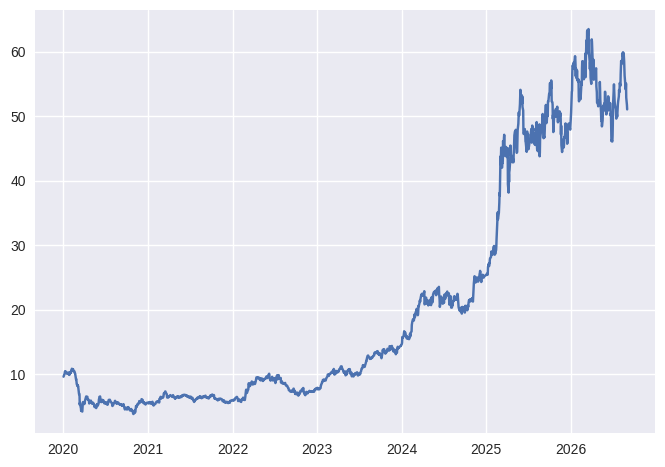

In [69]:
plt.plot(data["Close"])
plt.show()

The moving averages are 20 and 60 days

In [66]:
data["SMA"] = data["Close"].rolling(20).mean()
data["LMA"] = data["Close"].rolling(60).mean()
print(data)

Price           Close       High        Low       Open   Volume      SMA  \
Ticker         LDO.MI     LDO.MI     LDO.MI     LDO.MI   LDO.MI            
Date                                                                       
2020-01-02   9.623544   9.770538   9.614356   9.646511  1264225      NaN   
2020-01-03   9.720010   9.720010   9.559234   9.591389  1569605      NaN   
2020-01-06   9.991030  10.004811   9.591388   9.720009  3268214      NaN   
2020-01-07  10.124244  10.243676  10.036966  10.050746  3649794      NaN   
2020-01-08  10.427420  10.427420   9.986436  10.124244  4011434      NaN   
...               ...        ...        ...        ...      ...      ...   
2026-08-26  54.119999  54.770000  53.610001  54.220001  1640135  57.2320   
2026-08-27  55.049999  55.680000  53.790001  54.380001  2078563  57.2985   
2026-08-28  52.869999  55.580002  52.869999  55.580002  2549622  57.1860   
2026-08-31  51.720001  53.080002  51.610001  52.959999  2263258  57.0365   
2026-09-01  

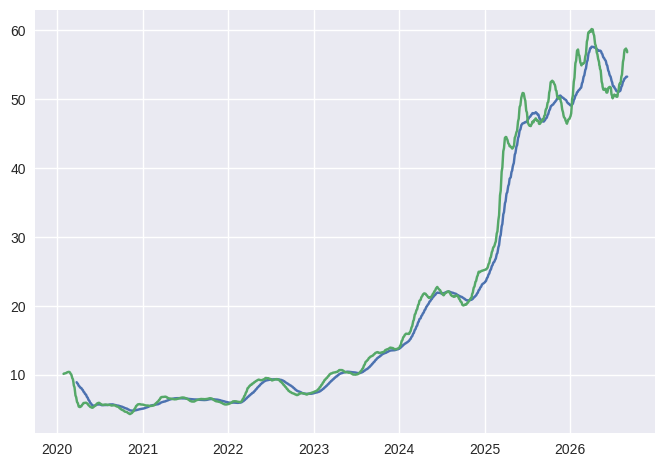

In [67]:
plt.plot(data["LMA"])
plt.plot(data["SMA"])
plt.show()

We define the strategy with the where functions from numpy


In [57]:
#definiamo la strategia

data["strategia"] = np.where(data["SMA"]>data["LMA"],+1,-1)
print(data)

Price           Close       High        Low       Open   Volume      SMA  \
Ticker         LDO.MI     LDO.MI     LDO.MI     LDO.MI   LDO.MI            
Date                                                                       
2020-01-02   9.623544   9.770538   9.614356   9.646511  1264225      NaN   
2020-01-03   9.720009   9.720009   9.559233   9.591388  1569605      NaN   
2020-01-06   9.991030  10.004811   9.591388   9.720009  3268214      NaN   
2020-01-07  10.124245  10.243677  10.036966  10.050747  3649794      NaN   
2020-01-08  10.427420  10.427420   9.986436  10.124244  4011434      NaN   
...               ...        ...        ...        ...      ...      ...   
2026-08-26  54.119999  54.770000  53.610001  54.220001  1640135  57.2320   
2026-08-27  55.049999  55.680000  53.790001  54.380001  2078563  57.2985   
2026-08-28  52.869999  55.580002  52.869999  55.580002  2549622  57.1860   
2026-08-31  51.720001  53.080002  51.610001  52.959999  2263258  57.0365   
2026-09-01  

Transoform the close price into logaritmic values, so we can add directly the % change onto the base of 100

In [58]:
data["price"] = np.log(data["Close"]/data["Close"].shift(1))
print(data)

Price           Close       High        Low       Open   Volume      SMA  \
Ticker         LDO.MI     LDO.MI     LDO.MI     LDO.MI   LDO.MI            
Date                                                                       
2020-01-02   9.623544   9.770538   9.614356   9.646511  1264225      NaN   
2020-01-03   9.720009   9.720009   9.559233   9.591388  1569605      NaN   
2020-01-06   9.991030  10.004811   9.591388   9.720009  3268214      NaN   
2020-01-07  10.124245  10.243677  10.036966  10.050747  3649794      NaN   
2020-01-08  10.427420  10.427420   9.986436  10.124244  4011434      NaN   
...               ...        ...        ...        ...      ...      ...   
2026-08-26  54.119999  54.770000  53.610001  54.220001  1640135  57.2320   
2026-08-27  55.049999  55.680000  53.790001  54.380001  2078563  57.2985   
2026-08-28  52.869999  55.580002  52.869999  55.580002  2549622  57.1860   
2026-08-31  51.720001  53.080002  51.610001  52.959999  2263258  57.0365   
2026-09-01  

In [59]:

strat = data["price"]*data["strategia"].shift(1)
print(strat.sum(), data["price"].sum())

1.9198720864275214 1.666632205727166
